In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.fft import fft, fftfreq
from statsmodels.tsa.stattools import acf

# ============================================================
# PARAMÈTRES DES ÉCHELLES  (Borland-Bouchaud 2005)
# ============================================================
alpha_BB = 1.15          # exposant empirique
L_min, L_max = 1, 500   # horizon min/max (en pas de simulation)
K = 10                   # nombre d'échelles

ells         = np.logspace(np.log10(L_min), np.log10(L_max), K)
alphas_multi = 1.0 / ells   # mémoire exponentielle : alpha_ℓ = 1/ℓ

# ============================================================
# MODÈLE DE CHIARELLA MULTI-ÉCHELLES
# ============================================================
def simulate_chiarella(NIT, kappa, kappa_3, beta_total, gamma, lst_alpha,
                       sigmaN, sigmaV, P0, V0, g=0.0011):
    """
    Modèle de Chiarella multi-échelles.
    - Betas fixes en loi de puissance (Borland-Bouchaud).
    - lst_alpha=[x] → mono-échelle classique.
    """
    P = np.zeros(NIT); V = np.zeros(NIT)
    alphas = np.array(lst_alpha); K = len(alphas)
    M = np.zeros((K, NIT))

    # Betas : décroissants en loi de puissance pour K>1
    if K > 1:
        raw  = 1.0 / ells**alpha_BB
        beta = beta_total * raw / raw.sum()
    else:
        beta = np.array([beta_total])

    epsilons = np.random.normal(0, sigmaN, NIT)
    etas     = np.random.normal(0, sigmaV, NIT)
    P[0] = P0; P[1] = P0
    V[0] = V0; V[1] = V0 + g

    for t in range(1, NIT - 1):
        signals          = np.tanh(gamma * M[:, t])
        chartist_demand  = np.dot(beta, signals)
        P[t+1] = (P[t]
                  + kappa * (V[t] - P[t])
                  + chartist_demand
                  + kappa_3 * (V[t] - P[t])**3
                  + epsilons[t+1])
        V[t+1] = V[t] + g + etas[t+1]
        for i in range(K):
            M[i, t+1] = (1 - alphas[i]) * M[i, t] + alphas[i] * (P[t] - P[t-1])
    return P, V

# ============================================================
# FONCTIONS D'ANALYSE
# ============================================================
def get_bubble_stats(P, V):
    """Durées, amplitudes et mispricing de chaque excursion P≠V."""
    delta  = P - V
    signs  = np.sign(delta); signs[signs == 0] = 1
    crossings = np.where(np.diff(signs) != 0)[0]
    if len(crossings) == 0:
        return np.array([len(P)]), np.array([np.max(np.abs(delta))]), delta
    boundaries = np.concatenate([[0], crossings, [len(delta)]])
    durations, amplitudes = [], []
    for k in range(len(boundaries) - 1):
        seg = delta[boundaries[k]:boundaries[k+1]]
        if len(seg) == 0: continue
        durations.append(len(seg))
        amplitudes.append(np.max(np.abs(seg)))
    return np.array(durations), np.array(amplitudes), delta


def hurst_exponent(ts):
    """
    Exposant de Hurst par analyse R/S.
    H > 0.5 → longue mémoire, H = 0.5 → marche aléatoire.
    """
    lags = range(2, 50)
    tau  = [np.std(np.subtract(ts[l:], ts[:-l])) for l in lags]
    return np.polyfit(np.log(lags), np.log(tau), 1)[0]


def zumbach_score(returns, lh=50, lf=5):
    """
    Asymétrie temporelle de Zumbach & Lynch (2003).
    Score = corr(vol_passée_grande_échelle, vol_future_petite_échelle)
          - corr(vol_passée_petite_échelle, vol_future_grande_échelle)
    > 0 : asymétrie temporelle (non-TRS) — signature du modèle multi-échelles.
    = 0 : symétrie temporelle (marche aléatoire, modèles multifractals classiques).
    """
    n     = len(returns)
    start = max(lh, lf)
    vph   = np.array([np.std(returns[max(0,t-lh):t])  for t in range(start, n-lf)])
    vpf_f = np.array([np.std(returns[t:t+lf])          for t in range(start, n-lf)])
    vpl   = np.array([np.std(returns[max(0,t-lf):t])  for t in range(start, n-lh)])
    vpf_h = np.array([np.std(returns[t:t+lh])          for t in range(start, n-lh)])
    mn    = min(len(vph), len(vpf_f), len(vpl), len(vpf_h))
    c1 = np.corrcoef(vph[:mn], vpf_f[:mn])[0, 1]   # grande → petite
    c2 = np.corrcoef(vpl[:mn], vpf_h[:mn])[0, 1]   # petite → grande
    return c1 - c2


# Calibration JP
params = dict(
    NIT=2000,
    kappa=-0.011, kappa_3=0.269,
    beta_total=0.018, gamma=25,
    sigmaN=0.057, sigmaV=0.018,
    P0=7.94, V0=7.94, g=0.0024
)


In [2]:
# ============================================================
# SIMULATION COMPARATIVE : Mono vs Multi
# ============================================================
np.random.seed(0)

P_m, V_m = simulate_chiarella(**params, lst_alpha=alphas_multi)
P_s, V_s = simulate_chiarella(**params, lst_alpha=[0.7])

durations_m, amplitudes_m, delta_m = get_bubble_stats(P_m, V_m)
durations_s, amplitudes_s, delta_s = get_bubble_stats(P_s, V_s)

returns_m = np.diff(np.log(np.clip(P_m, 1e-6, None)))
returns_s = np.diff(np.log(np.clip(P_s, 1e-6, None)))

H_m = hurst_exponent(delta_m)
H_s = hurst_exponent(delta_s)
Z_m = zumbach_score(returns_m)
Z_s = zumbach_score(returns_s)
r_m = np.corrcoef(durations_m, amplitudes_m)[0, 1]
r_s = np.corrcoef(durations_s, amplitudes_s)[0, 1]

print("=" * 62)
print(f"{'Statistique':<32} {'Mono':>12} {'Multi':>12}")
print("=" * 62)
print(f"{'Std(mispricing)':<32} {np.std(delta_s):>12.4f} {np.std(delta_m):>12.4f}")
print(f"{'Max|mispricing|':<32} {np.max(np.abs(delta_s)):>12.4f} {np.max(np.abs(delta_m)):>12.4f}")
print(f"{'Durée moy. bulles':<32} {np.mean(durations_s):>12.1f} {np.mean(durations_m):>12.1f}")
print(f"{'Amplitude moy. bulles':<32} {np.mean(amplitudes_s):>12.4f} {np.mean(amplitudes_m):>12.4f}")
print(f"{'Kurtosis des returns':<32} {stats.kurtosis(returns_s, fisher=False):>12.2f} {stats.kurtosis(returns_m, fisher=False):>12.2f}")
print(f"{'Exposant de Hurst (mispricing)':<32} {H_s:>12.3f} {H_m:>12.3f}")
print(f"{'Score Zumbach (asymétrie temp.)':<32} {Z_s:>12.4f} {Z_m:>12.4f}")
print(f"{'Corr(durée, amplitude)':<32} {r_s:>12.3f} {r_m:>12.3f}")
print("=" * 62)


Statistique                              Mono        Multi
Std(mispricing)                        0.2516       0.2775
Max|mispricing|                        0.7542       0.6471
Durée moy. bulles                        14.8         22.5
Amplitude moy. bulles                  0.1668       0.1941
Kurtosis des returns                     3.12         3.09
Exposant de Hurst (mispricing)          0.409        0.438
Score Zumbach (asymétrie temp.)        0.0284       0.0101
Corr(durée, amplitude)                  0.900        0.832


/var/folders/8m/kh5fv87n5jb5_xz15b7t5wv80000gn/T/ipykernel_31528/266030160.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


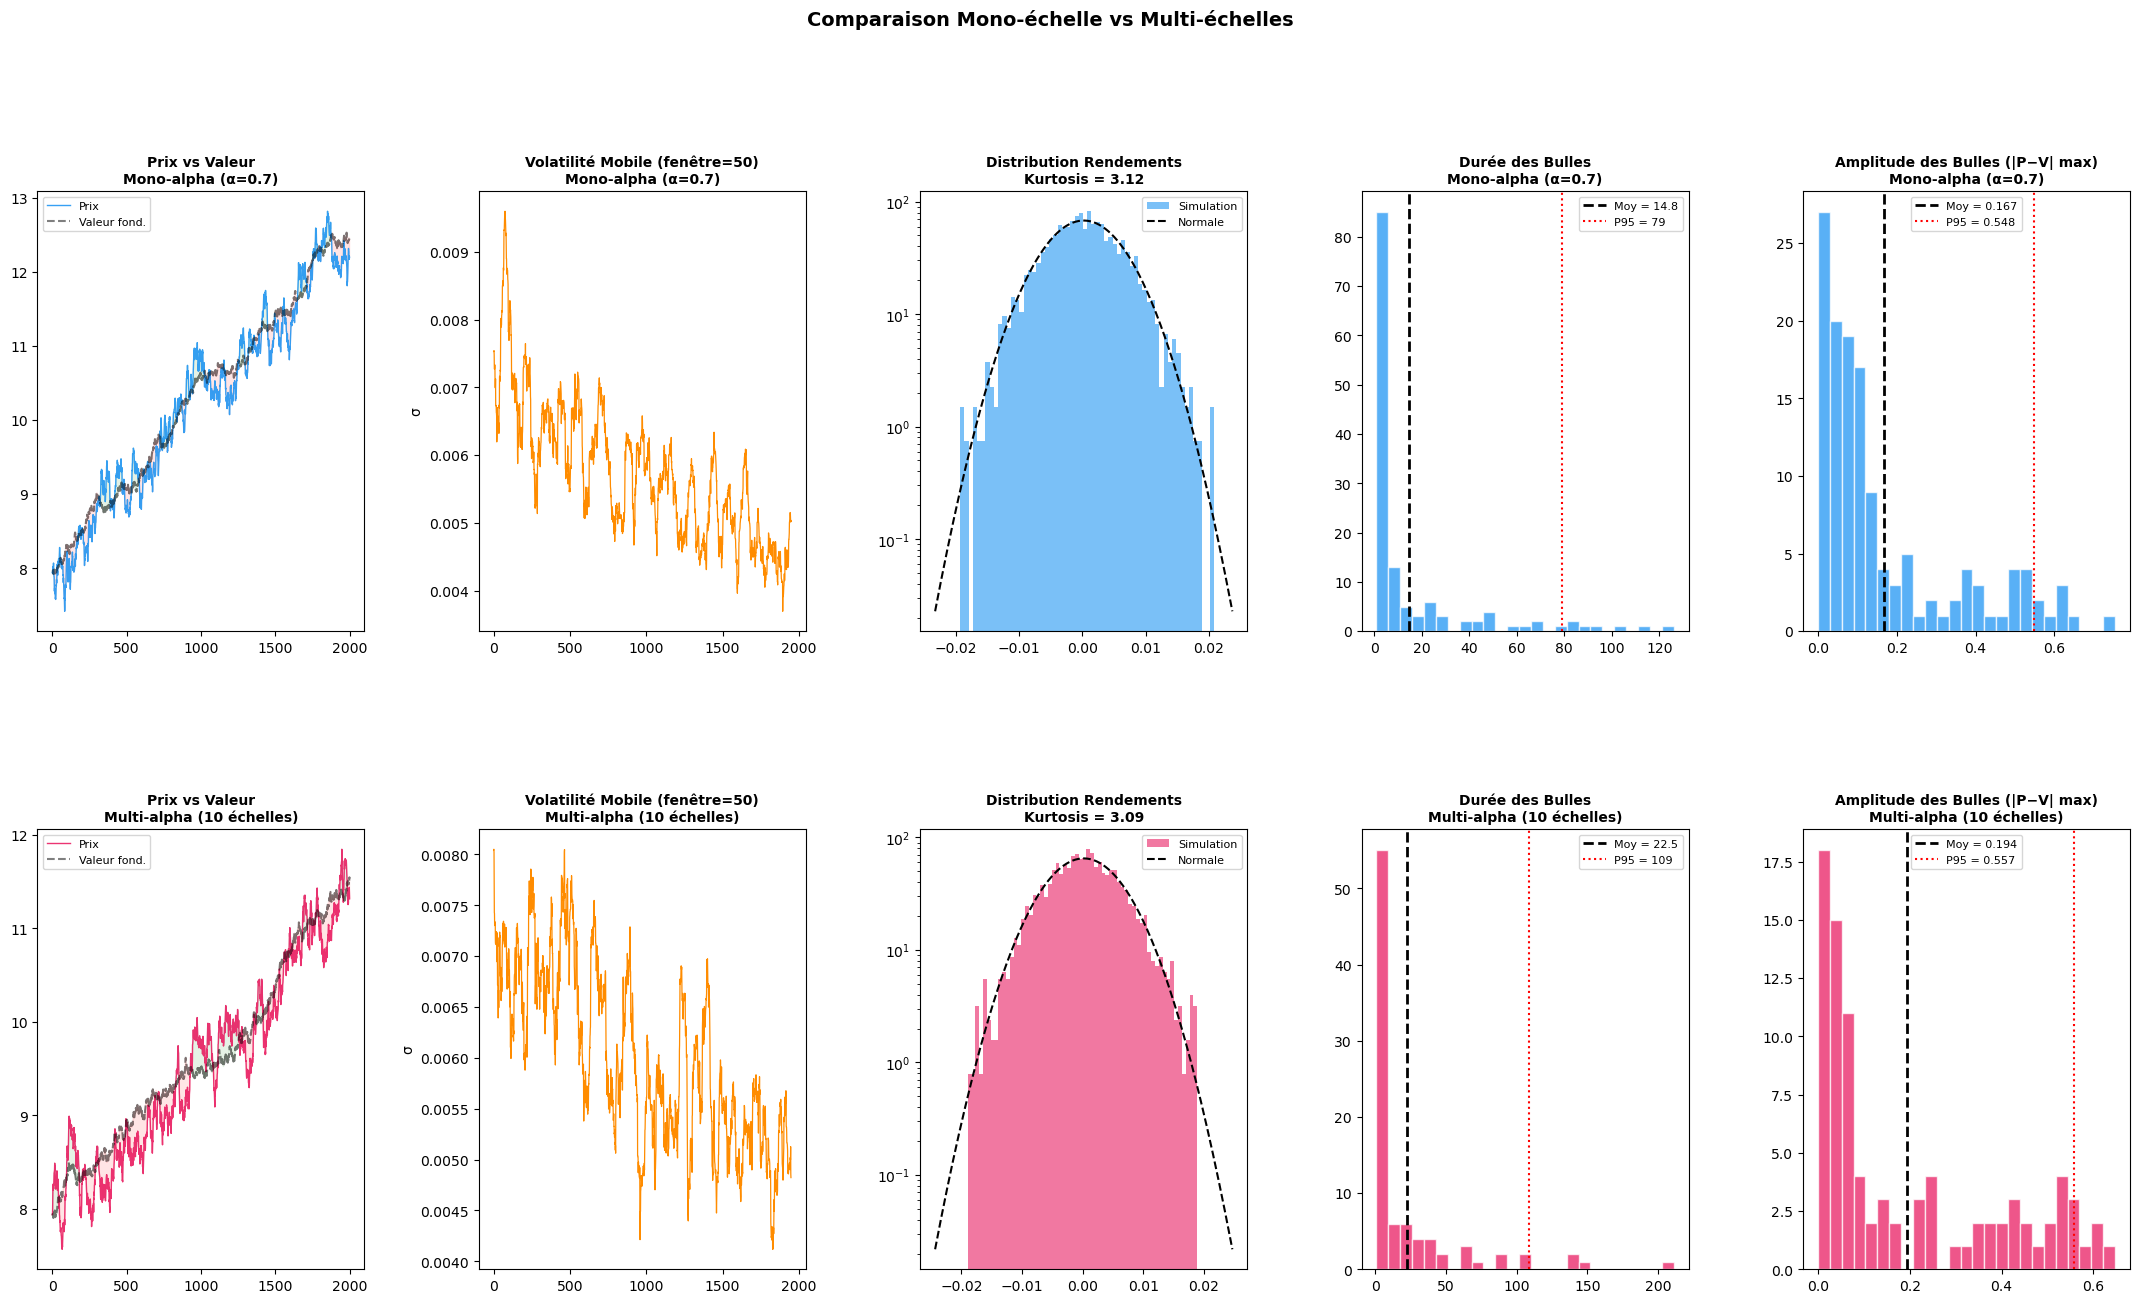

In [3]:
# ============================================================
# GRAPHIQUES COMPARATIFS — BULLES & RENDEMENTS
# ============================================================
fig = plt.figure(figsize=(27, 14))
gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.45, wspace=0.35)

labels       = ["Mono-alpha (α=0.7)", "Multi-alpha (10 échelles)"]
colors_model = ["#2196F3", "#E91E63"]

for idx, (P, V, label, col) in enumerate(
        [(P_s, V_s, labels[0], colors_model[0]),
         (P_m, V_m, labels[1], colors_model[1])]):

    durations, amplitudes, delta = get_bubble_stats(P, V)
    returns = np.diff(np.log(np.clip(P, 1e-6, None)))
    window  = 50
    volatility = [np.std(returns[i:i+window]) for i in range(len(returns)-window)]
    row = idx

    # Col 0 : Prix vs Valeur
    ax = fig.add_subplot(gs[row, 0])
    ax.plot(P, lw=1, color=col, alpha=0.9, label="Prix")
    ax.plot(V, lw=1.5, ls="--", color="black", alpha=0.5, label="Valeur fond.")
    ax.fill_between(range(len(P)), P, V, where=(P>V), alpha=0.1, color='green')
    ax.fill_between(range(len(P)), P, V, where=(P<V), alpha=0.1, color='red')
    ax.set_title(f"Prix vs Valeur\n{label}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # Col 1 : Volatilité mobile
    ax = fig.add_subplot(gs[row, 1])
    ax.plot(volatility, color="darkorange", lw=0.9)
    ax.set_title(f"Volatilité Mobile (fenêtre={window})\n{label}", fontsize=10, fontweight='bold')
    ax.set_ylabel("σ")

    # Col 2 : Distribution des returns
    ax = fig.add_subplot(gs[row, 2])
    ax.hist(returns, bins=60, density=True, alpha=0.6, color=col, label="Simulation")
    mu_r, sig_r = np.mean(returns), np.std(returns)
    x = np.linspace(mu_r - 4*sig_r, mu_r + 4*sig_r, 200)
    ax.plot(x, stats.norm.pdf(x, mu_r, sig_r), 'k--', lw=1.5, label="Normale")
    ax.set_yscale('log')
    ax.set_title(f"Distribution Rendements\nKurtosis = {stats.kurtosis(returns, fisher=False):.2f}",
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # Col 3 : Distribution durées
    ax = fig.add_subplot(gs[row, 3])
    ax.hist(durations, bins=25, color=col, edgecolor='white', alpha=0.75)
    ax.axvline(np.mean(durations), color='black', lw=2, ls='--',
               label=f"Moy = {np.mean(durations):.1f}")
    ax.axvline(np.percentile(durations, 95), color='red', lw=1.5, ls=':',
               label=f"P95 = {np.percentile(durations, 95):.0f}")
    ax.set_title(f"Durée des Bulles\n{label}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

    # Col 4 : Distribution amplitudes
    ax = fig.add_subplot(gs[row, 4])
    ax.hist(amplitudes, bins=25, color=col, edgecolor='white', alpha=0.75)
    ax.axvline(np.mean(amplitudes), color='black', lw=2, ls='--',
               label=f"Moy = {np.mean(amplitudes):.3f}")
    ax.axvline(np.percentile(amplitudes, 95), color='red', lw=1.5, ls=':',
               label=f"P95 = {np.percentile(amplitudes, 95):.3f}")
    ax.set_title(f"Amplitude des Bulles (|P−V| max)\n{label}", fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle("Comparaison Mono-échelle vs Multi-échelles",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


/var/folders/8m/kh5fv87n5jb5_xz15b7t5wv80000gn/T/ipykernel_31528/2332085765.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


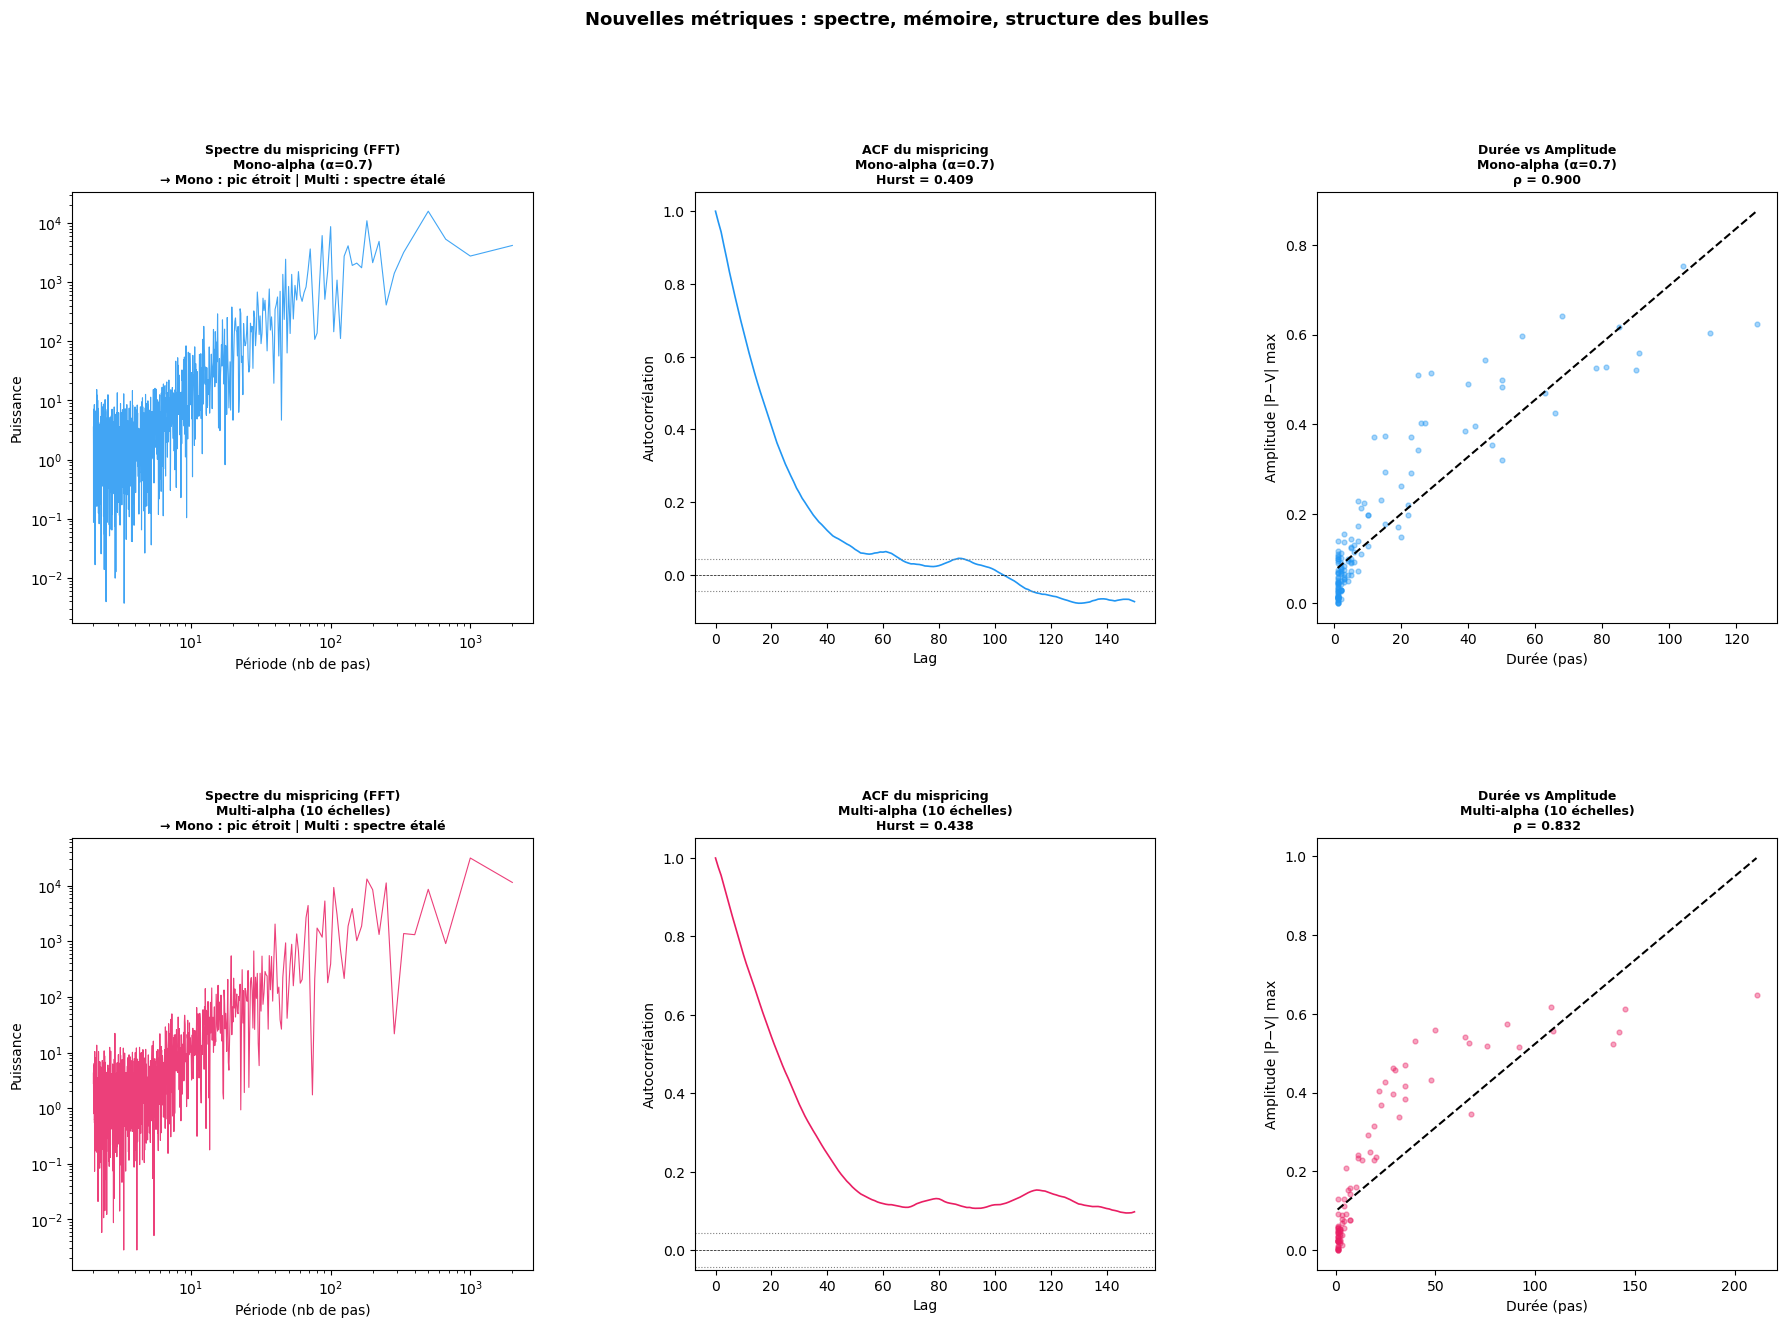


=== Asymétrie temporelle de Zumbach ===
Score = corr(vol_passée_grande, vol_future_petite) - corr(vol_passée_petite, vol_future_grande)
  > 0 : asymétrie temporelle (signature multi-échelles)
  ≈ 0 : symétrie temporelle (marche aléatoire, modèles multifractals classiques)

  Horizons ( 10 →  1) | Mono : +nan | Multi : +nan
  Horizons ( 50 →  5) | Mono : +0.0284 | Multi : +0.0101


/Users/marcbrgv/miniforge3/envs/fenics_env/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/marcbrgv/miniforge3/envs/fenics_env/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


  Horizons (200 → 20) | Mono : +0.0355 | Multi : +0.0016


In [4]:
# ============================================================
# NOUVELLES MÉTRIQUES SUR UNE ITÉRATION
# ============================================================
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.35)

colors_model = ["#2196F3", "#E91E63"]
labels       = ["Mono-alpha (α=0.7)", "Multi-alpha (10 échelles)"]

for idx, (P, V, label, col) in enumerate(
        [(P_s, V_s, labels[0], colors_model[0]),
         (P_m, V_m, labels[1], colors_model[1])]):

    durations, amplitudes, delta = get_bubble_stats(P, V)
    returns = np.diff(np.log(np.clip(P, 1e-6, None)))
    row = idx

    # --- Col 0 : Spectre de puissance du mispricing (FFT) ---
    ax = fig.add_subplot(gs[row, 0])
    N_fft  = len(delta)
    freqs  = fftfreq(N_fft)[1:N_fft//2]
    power  = np.abs(fft(delta))[1:N_fft//2]**2
    periods = 1.0 / freqs
    ax.plot(periods, power, lw=0.8, color=col, alpha=0.85)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("Période (nb de pas)")
    ax.set_ylabel("Puissance")
    ax.set_title(f"Spectre du mispricing (FFT)\n{label}\n"
                 f"→ Mono : pic étroit | Multi : spectre étalé",
                 fontsize=9, fontweight='bold')

    # --- Col 1 : ACF du mispricing ---
    ax = fig.add_subplot(gs[row, 1])
    acf_vals = acf(delta, nlags=150, fft=True)
    ax.plot(acf_vals, color=col, lw=1.2)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.axhline( 1.96/np.sqrt(len(delta)), color='gray', lw=0.8, ls=':')
    ax.axhline(-1.96/np.sqrt(len(delta)), color='gray', lw=0.8, ls=':')
    H_val = hurst_exponent(delta)
    ax.set_title(f"ACF du mispricing\n{label}\nHurst = {H_val:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("Lag"); ax.set_ylabel("Autocorrélation")

    # --- Col 2 : Durée vs Amplitude (scatter) ---
    ax = fig.add_subplot(gs[row, 2])
    ax.scatter(durations, amplitudes, alpha=0.4, s=12, color=col)
    r_val = np.corrcoef(durations, amplitudes)[0, 1]
    # Régression linéaire
    m_coef, b_coef = np.polyfit(durations, amplitudes, 1)
    x_line = np.linspace(durations.min(), durations.max(), 100)
    ax.plot(x_line, m_coef*x_line + b_coef, 'k--', lw=1.5)
    ax.set_xlabel("Durée (pas)"); ax.set_ylabel("Amplitude |P−V| max")
    ax.set_title(f"Durée vs Amplitude\n{label}\nρ = {r_val:.3f}",
                 fontsize=9, fontweight='bold')

plt.suptitle("Nouvelles métriques : spectre, mémoire, structure des bulles",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Asymétrie temporelle de Zumbach (tableau) ---
print("\n=== Asymétrie temporelle de Zumbach ===")
print("Score = corr(vol_passée_grande, vol_future_petite) - corr(vol_passée_petite, vol_future_grande)")
print("  > 0 : asymétrie temporelle (signature multi-échelles)")
print("  ≈ 0 : symétrie temporelle (marche aléatoire, modèles multifractals classiques)\n")
for lh, lf in [(10,1), (50,5), (200,20)]:
    z_m = zumbach_score(returns_m, lh=lh, lf=lf)
    z_s = zumbach_score(returns_s, lh=lh, lf=lf)
    print(f"  Horizons ({lh:3d} → {lf:2d}) | Mono : {z_s:+.4f} | Multi : {z_m:+.4f}")


In [ ]:
# ============================================================
# VALIDATION MONTE CARLO ÉTENDUE
# ============================================================
N = 1000

results = {
    # Métriques existantes
    'dur_m':      np.zeros(N), 'dur_s':      np.zeros(N),
    'std_m':      np.zeros(N), 'std_s':      np.zeros(N),
    'dur95_m':    np.zeros(N), 'dur95_s':    np.zeros(N),
    'amp_m':      np.zeros(N), 'amp_s':      np.zeros(N),
    'amp95_m':    np.zeros(N), 'amp95_s':    np.zeros(N),
    # Nouvelles métriques
    'hurst_m':    np.zeros(N), 'hurst_s':    np.zeros(N),   # longue mémoire
    'cv_dur_m':   np.zeros(N), 'cv_dur_s':   np.zeros(N),   # hétérogénéité des bulles
    'freq_ext_m': np.zeros(N), 'freq_ext_s': np.zeros(N),   # fréquence des grandes bulles
    'zumbach_m':  np.zeros(N), 'zumbach_s':  np.zeros(N),   # asymétrie temporelle
}

# Seuil pour les "grandes bulles" (à ajuster selon calibration)
seuil_amp = np.percentile(amplitudes_m, 75)  # P75 comme référence dynamique

for i in range(N):
    P_m_i, V_m_i = simulate_chiarella(**params, lst_alpha=alphas_multi)
    P_s_i, V_s_i = simulate_chiarella(**params, lst_alpha=[0.7])

    d_m_i, amp_m_i, delta_m_i = get_bubble_stats(P_m_i, V_m_i)
    d_s_i, amp_s_i, delta_s_i = get_bubble_stats(P_s_i, V_s_i)

    ret_m_i = np.diff(np.log(np.clip(P_m_i, 1e-6, None)))
    ret_s_i = np.diff(np.log(np.clip(P_s_i, 1e-6, None)))

    # Métriques existantes
    results['dur_m'][i]   = np.mean(d_m_i);   results['dur_s'][i]   = np.mean(d_s_i)
    results['std_m'][i]   = np.std(delta_m_i); results['std_s'][i]   = np.std(delta_s_i)
    results['dur95_m'][i] = np.percentile(d_m_i, 95)
    results['dur95_s'][i] = np.percentile(d_s_i, 95)
    results['amp_m'][i]   = np.mean(amp_m_i); results['amp_s'][i]   = np.mean(amp_s_i)
    results['amp95_m'][i] = np.percentile(amp_m_i, 95)
    results['amp95_s'][i] = np.percentile(amp_s_i, 95)

    # Nouvelles métriques
    results['hurst_m'][i]    = hurst_exponent(delta_m_i)
    results['hurst_s'][i]    = hurst_exponent(delta_s_i)
    results['cv_dur_m'][i]   = np.std(d_m_i) / np.mean(d_m_i) if np.mean(d_m_i) > 0 else 0
    results['cv_dur_s'][i]   = np.std(d_s_i) / np.mean(d_s_i) if np.mean(d_s_i) > 0 else 0
    results['freq_ext_m'][i] = np.mean(amp_m_i > seuil_amp)
    results['freq_ext_s'][i] = np.mean(amp_s_i > seuil_amp)
    results['zumbach_m'][i]  = zumbach_score(ret_m_i)
    results['zumbach_s'][i]  = zumbach_score(ret_s_i)

# ── Graphiques ───────────────────────────────────────────────────────────────
metrics_plot = [
    ('dur_s',      'dur_m',      'Durée moy. bulles'),
    ('amp_s',      'amp_m',      'Amplitude moy. bulles'),
    ('dur95_s',    'dur95_m',    'Durée P95 bulles'),
    ('amp95_s',    'amp95_m',    'Amplitude P95 bulles'),
    ('hurst_s',    'hurst_m',    'Exposant de Hurst'),
    ('cv_dur_s',   'cv_dur_m',   'CV des durées (std/moy)'),
    ('freq_ext_s', 'freq_ext_m', 'Fréq. grandes bulles'),
    ('zumbach_s',  'zumbach_m',  'Score Zumbach'),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (key_s, key_m, title) in zip(axes, metrics_plot):
    ax.hist(results[key_s], bins=30, alpha=0.6, color='#2196F3',
            label=f"Mono  ({np.mean(results[key_s]):.3f})")
    ax.hist(results[key_m], bins=30, alpha=0.6, color='#E91E63',
            label=f"Multi ({np.mean(results[key_m]):.3f})")
    _, p_val = stats.ttest_ind(results[key_m], results[key_s])
    ax.set_title(f"{title}\np = {p_val:.4f} "
                 f"({'✓' if p_val < 0.05 else '✗'})",
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel("Valeur")

plt.suptitle(f"Monte Carlo — {N} simulations | Mono vs Multi-échelles",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Résumé textuel ───────────────────────────────────────────────────────────
print(f"\n{'Métrique':<32} {'Mono':>8} {'Multi':>8} {'Δ%':>8} {'p-val':>8} {'Sig.':>5}")
print("─" * 70)
for key_s, key_m, title in metrics_plot:
    m_s  = np.mean(results[key_s])
    m_m  = np.mean(results[key_m])
    diff = 100 * (m_m - m_s) / abs(m_s) if m_s != 0 else float('nan')
    _, p = stats.ttest_ind(results[key_m], results[key_s])
    sig  = "✓" if p < 0.05 else "✗"
    print(f"{title:<32} {m_s:>8.3f} {m_m:>8.3f} {diff:>+7.1f}% {p:>8.4f} {sig:>5}")
